# 1.Category Contribution and Reviews Distribution

/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_50553/1277736165.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA + 'order_items.csv')


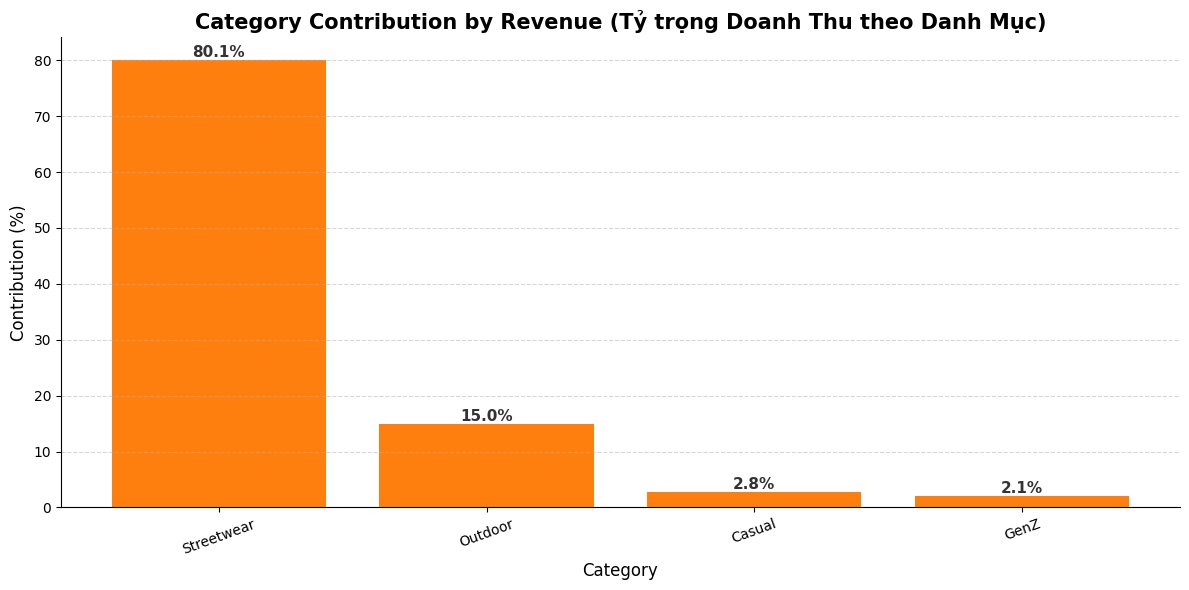

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
BASE_DATA = "data/"
products = pd.read_csv(BASE_DATA + 'products.csv')
order_items = pd.read_csv(BASE_DATA + 'order_items.csv')

# 2. Merge dữ liệu để lấy category cho từng item dựa vào product_id
order_items_merged = order_items.merge(products[['product_id', 'category']], on='product_id', how='inner')

# 3. Tính doanh thu (Revenue) cho mỗi sản phẩm bán ra
order_items_merged['revenue'] = (order_items_merged['quantity'] * order_items_merged['unit_price']) - order_items_merged['discount_amount'].fillna(0)

# 4. Gom nhóm tính tổng doanh thu theo Category 
category_revenue = order_items_merged.groupby('category')['revenue'].sum().sort_values(ascending=False)

# 5. Phân tích tỷ trọng phần trăm (Contribution)
total_revenue = category_revenue.sum()
category_percentage = (category_revenue / total_revenue) * 100

# ==========================================
# Vẽ biểu đồ Bar Chart Percentage
# ==========================================
plt.figure(figsize=(12, 6))
bars = plt.bar(category_percentage.index, category_percentage.values, color='#ff7f0e')

# Thêm số % lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#333333')

plt.title('Category Contribution by Revenue (Tỷ trọng Doanh Thu theo Danh Mục)', fontsize=15, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Contribution (%)', fontsize=12)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Bỏ viền thừa của biểu đồ cho thiết kế thanh thoát hơn
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


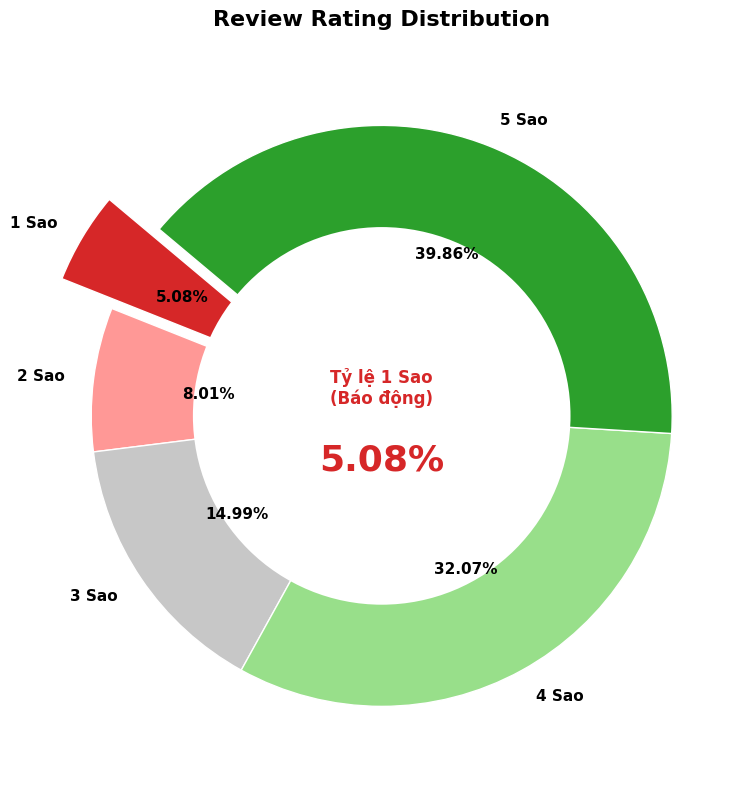

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu đánh giá
BASE_DATA = "data/"
reviews = pd.read_csv(BASE_DATA + 'reviews.csv')

# 2. Đếm số lượng theo giá trị rating (từ 1 đến 5 sao)
rating_counts = reviews['rating'].value_counts()
total_reviews = len(reviews)

# Chuẩn hóa thứ tự index từ 1 đến 5 sao (với mapping string)
mapping = {1: '1 Sao', 2: '2 Sao', 3: '3 Sao', 4: '4 Sao', 5: '5 Sao'}
rating_counts.index = rating_counts.index.map(mapping)
rating_counts = rating_counts.reindex(['1 Sao', '2 Sao', '3 Sao', '4 Sao', '5 Sao']).fillna(0)

# 3. Tính % tỷ lệ phân bổ của các sao
percentage = rating_counts / total_reviews

# ==========================================
# Vẽ biểu đồ Donut Chart (Highlight 1 Sao bị vỡ ra khỏi bánh)
# ==========================================
# Set màu: Trắng/đỏ để nhấn mạnh sự tiêu cực của 1 sao, các review cao dần thì xanh lá
colors = ['#d62728', '#ff9896', '#c7c7c7', '#98df8a', '#2ca02c'] 
explode = (0.2, 0, 0, 0, 0)  # Tách lát cắt 1 sao (index 0) ra khỏi bánh

plt.figure(figsize=(8, 8))
plt.pie(percentage, explode=explode, labels=percentage.index, colors=colors, 
        autopct='%1.2f%%', startangle=140, textprops={'fontsize': 11, 'weight': 'bold'},
        wedgeprops=dict(edgecolor='w'))

# Thêm vòng tròn trắng ở giữa để tạo thành Donut chart đương đại
centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# In số liệu đúc kết của phần 1 Sao ngay ở giữa tâm chart!
one_star_pct = percentage.get('1 Sao', 0)
plt.text(0, 0.1, 'Tỷ lệ 1 Sao\n(Báo động)', ha='center', va='center', fontsize=12, color='#d62728', fontweight='bold')
plt.text(0, -0.15, f'{one_star_pct:.2%}', ha='center', va='center', fontsize=26, color='#d62728', fontweight='bold')

plt.title('Review Rating Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# 2. Sentiment Analysis

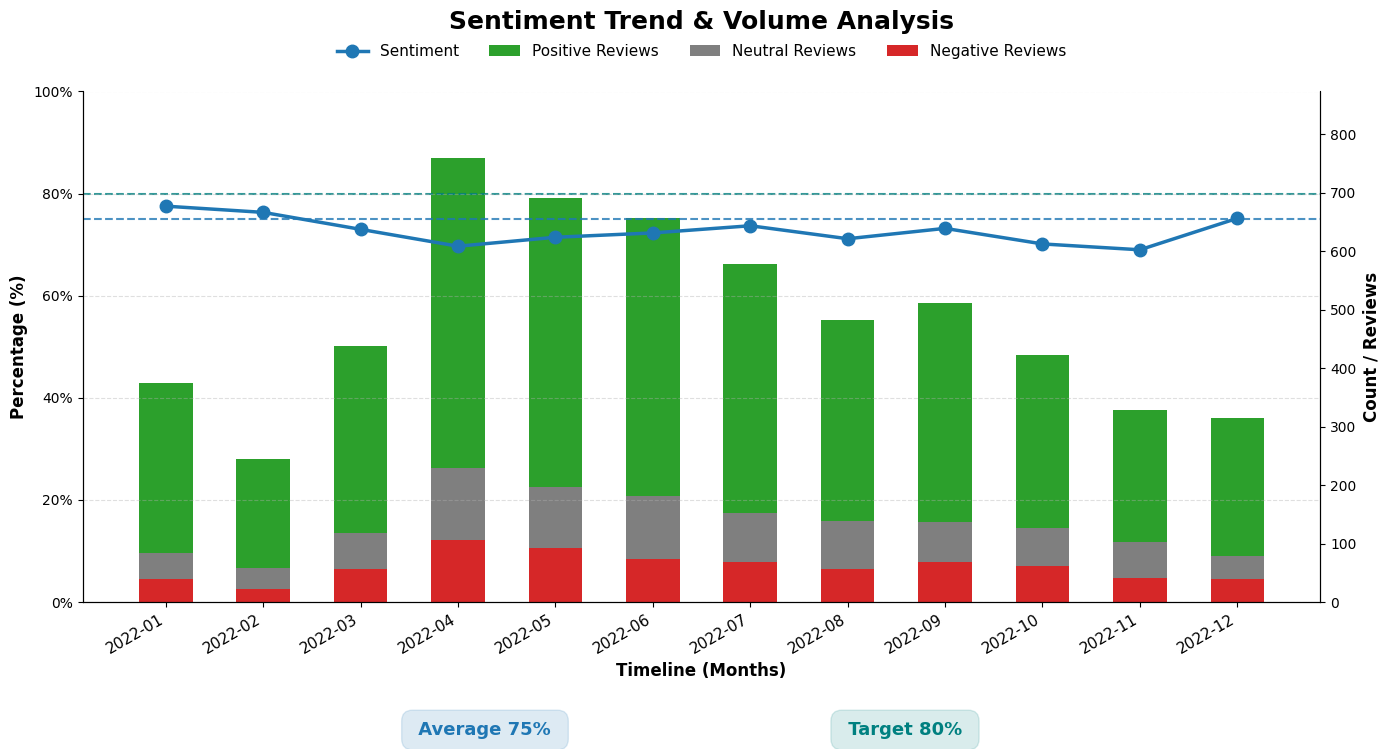

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# 1. Đọc và lọc dữ liệu (Lấy 12 tháng của năm 2022 để đồ thị có đúng 12 mốc như mô tả)
BASE_DATA = "data/"
reviews = pd.read_csv(BASE_DATA + 'reviews.csv', parse_dates=['review_date'])
reviews = reviews[reviews['review_date'].dt.year == 2022].copy()

# 2. Phân loại Cảm xúc (Sentiment Rating)
def classify_rating(r):
    if r in [1, 2]: return 'Negative'
    elif r == 3: return 'Neutral'
    else: return 'Positive'

reviews['sentiment'] = reviews['rating'].apply(classify_rating)
reviews['Month'] = reviews['review_date'].dt.to_period('M')

# Gom nhóm và tính toán Sentiment Percentage (Quy ước: % Positive)
pivot = reviews.groupby(['Month', 'sentiment']).size().unstack(fill_value=0)

# Đảm bảo có đủ 3 cột để code không lỗi nếu như tháng đó xui xẻo không có ai đánh giá 1 sao
for col in ['Negative', 'Neutral', 'Positive']:
    if col not in pivot.columns:
        pivot[col] = 0

pivot['Total'] = pivot['Negative'] + pivot['Neutral'] + pivot['Positive']
pivot['Sentiment_Pct'] = (pivot['Positive'] / pivot['Total']) * 100

x_labels = pivot.index.astype(str).tolist()
pos = pivot['Positive'].values
neu = pivot['Neutral'].values
neg = pivot['Negative'].values
sentiment_line = pivot['Sentiment_Pct'].values

# ==========================================
# VẼ BIỂU ĐỒ KÉP (DUAL AXIS CHART)
# ==========================================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Trục phụ ax2 (Cột chồng - Secondary Right Y-Axis)
ax2 = ax1.twinx()
width = 0.55
x_pos = np.arange(len(x_labels))

# Vẽ cột chồng (Stack order từ dưới lên: Red -> Gray -> Green)
p_neg = ax2.bar(x_pos, neg, width, label='Negative Reviews', color='#d62728', zorder=2)
p_neu = ax2.bar(x_pos, neu, width, bottom=neg, label='Neutral Reviews', color='#7f7f7f', zorder=2)
p_pos = ax2.bar(x_pos, pos, width, bottom=neg+neu, label='Positive Reviews', color='#2ca02c', zorder=2)

ax2.set_ylabel('Count / Reviews', fontsize=12, fontweight='bold')
# Trục tung bên phải tự động cấu hình khoảng cách từ 0 tới max Count + 15% (thay vì max 48 cố định)
ax2.set_ylim(0, max(pivot['Total']) * 1.15) 

# Đẩy trục ax1 lên trên ax2 để đường (Line) không bị những thanh cột lấp mất
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# Trục chính ax1 (Line - Primary Left Y-Axis)
p_line, = ax1.plot(x_pos, sentiment_line, color='#1f77b4', marker='o', markersize=9, 
                   linewidth=2.5, label='Sentiment', zorder=3)

ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(PercentFormatter())

# Hai Đường Tham Chiếu đứt đoạn (Reference Lines)
ax1.axhline(75, color='#1f77b4', linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)
ax1.axhline(80, color='#008080', linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)

# Format Trục hoành
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=11)
ax1.set_xlabel('Timeline (Months)', fontsize=12, fontweight='bold')

# Lưới (Gridlines) đồng bộ với trục Trái
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

# ==========================================
# CÁC YẾU TỐ HỖ TRỢ (LEGEND & SUMMARY BOXES)
# ==========================================
# 1. Chú giải (Legend)
handles = [p_line, p_pos, p_neu, p_neg]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False, fontsize=11)

# 2. Bảng tóm tắt (Summary Boxes) ở phía dưới biểu đồ
fig.text(0.35, -0.05, " Average 75% ", ha="center", va="center", fontsize=13,
         bbox=dict(facecolor="#1f77b4", alpha=0.15, edgecolor='#1f77b4', boxstyle='round,pad=0.6'), 
         color='#1f77b4', weight='bold')

fig.text(0.65, -0.05, " Target 80% ", ha="center", va="center", fontsize=13,
         bbox=dict(facecolor="#008080", alpha=0.15, edgecolor='#008080', boxstyle='round,pad=0.6'), 
         color='#008080', weight='bold')

# Tối ưu giao diện (Spines)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.title('Sentiment Trend & Volume Analysis', pad=45, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()
